In [1]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [40]:
import numpy as np
import skimage
import scipy
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import rootskel

In [54]:
roots = Image.open(r"./20260312_103230.jpg")
roots.mode # RGB is good

'RGB'

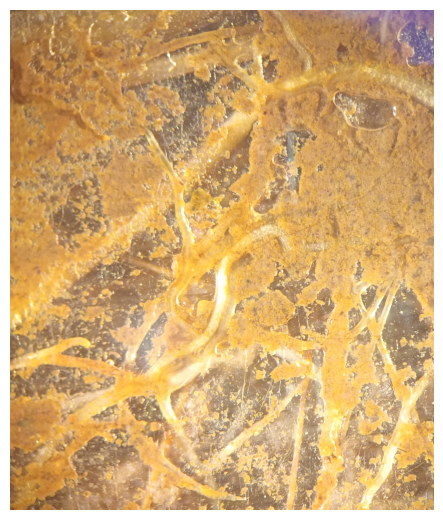

In [55]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(roots)
axes.set_axis_off()
plt.show()

In [58]:
roots = np.array(roots)
roots = cv2.cvtColor(src=roots, code=cv2.COLOR_RGB2GRAY) # greyscale transformation
cv2.threshold(src=roots, thresh=0, maxval=255, type=cv2.THRESH_BINARY+cv2.THRESH_OTSU, dst=roots) # transform the greyscale image to binary

(172.0,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(3966, 3356), dtype=uint8))

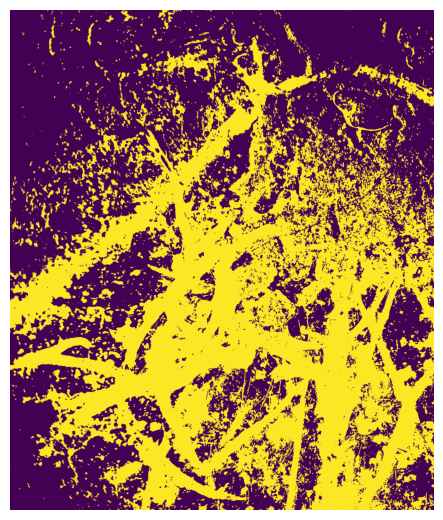

In [59]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(roots)
axes.set_axis_off()
plt.show()

In [60]:
nlabels, labels, stats, centroids = cv2.connectedComponentsWithStats(roots, 4, cv2.CV_32S)

In [61]:
labels # labels is a matrix the size of the input image where each element has a value equal to its label.

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3966, 3356), dtype=int32)

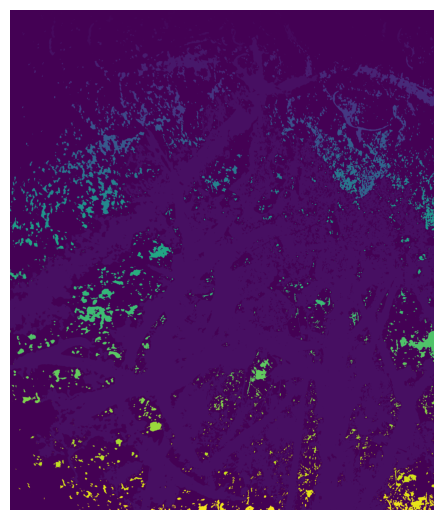

In [62]:
fig, axes = plt.subplots()
fig.set_size_inches(5.5, 6.5)
axes.imshow(labels)
axes.set_axis_off()
plt.show()

In [65]:
nlabels # number of labels

5395

In [64]:
stats # stats is a matrix of the stats that the function calculates. it has a length equal to the number of labels and a width equal to the number of stats
# it can be used with the OpenCV documentation for it

array([[      0,       0,    3356,    3966, 7092532],
       [    294,       0,      14,      14,     125],
       [    396,       0,       7,       9,      59],
       ...,
       [   2144,    3964,       4,       2,       7],
       [   2262,    3964,       5,       2,       7],
       [   3057,    3965,       2,       1,       2]],
      shape=(5395, 5), dtype=int32)

In [68]:
# stats computed by the function, for each label
cv2.CC_STAT_LEFT, cv2.CC_STAT_TOP, cv2.CC_STAT_WIDTH, cv2.CC_STAT_HEIGHT, cv2.CC_STAT_AREA

(0, 1, 2, 3, 4)